In [1]:
# Cell 1: Imports
import os
import numpy as np
import pandas as pd
import rasterio
import matplotlib.pyplot as plt
import pyproj
import cv2
from math import cos, radians
from rasterio.windows import from_bounds

print("✅ Imports loaded")

✅ Imports loaded


In [20]:
# Cell 2: Helper Functions

def get_craters_crs():
    """Get the CRS for crater coordinates"""
    craters_wkt = """
        GEOGCS["GCS_Moon",
        DATUM["D_Moon_2000",
        SPHEROID["Moon_2000_IAU_IAG",1737151.3,0, LENGTHUNIT["metre",1]]],
        PRIMEM["Reference_Meridian",0],
        UNIT["metre",1]],
        PROJECTION["Equirectangular"],
        PARAMETER["standard_parallel_1",0],
        PARAMETER["central_meridian",0],
        PARAMETER["false_easting",0],
        PARAMETER["false_northing",0],
        UNIT["metre",1, AUTHORITY["EPSG","9001"]],
        AXIS["Easting",EAST],
        AXIS["Northing",NORTH],
        AUTHORITY["ESRI","103881"]]
    """
    return pyproj.CRS.from_wkt(craters_wkt)


def flip_crater(img):
    '''
    ORIGINAL flip_crater function - EXACT replica.
    Flips crater s.t. the shadow will always be on the r.h.s
    '''
    qtr_img_width = np.int16(img.shape[1] / 4)
    half_img_width = np.int16(img.shape[1] / 2)

    left_crater_side = img[:, qtr_img_width:half_img_width]
    right_crater_side = img[:, half_img_width:-qtr_img_width]

    if left_crater_side.mean() > right_crater_side.mean():
        pass
    else:
        img = np.fliplr(img)

    return img


def crop_crater_original(map_ref, lat, lon, diameter, offset, transformer):
    """
    ORIGINAL method: Exact replica of your preprocessing.
    Crops with offset, stretches, then flips based on FULL image.
    """
    if lon > 180:
        lon -= 360
    
    # Convert latitude and longitude to map's coordinate system
    x, y = transformer.transform(lon, lat)
    
    # Define bounding box in projected coordinates
    radius = (diameter / 2) * 1000  # Convert km to meters
    radius_with_offset_x = (radius + radius * offset) / cos(radians(lat))
    radius_with_offset_y = radius + radius * offset
    min_x, min_y = x - radius_with_offset_x, y - radius_with_offset_y
    max_x, max_y = x + radius_with_offset_x, y + radius_with_offset_y

    # Get the window for cropping
    window = from_bounds(min_x, min_y, max_x, max_y, transform=map_ref.transform)

    # Read and crop the data
    cropped_image = map_ref.read(window=window)
    cropped_image = cropped_image.reshape((cropped_image.shape[1], cropped_image.shape[2]))

    # Latitude projection
    projected_height = int(cropped_image.shape[0] / cos(radians(abs(lat))))
    if projected_height > cropped_image.shape[0]:
        cropped_image_projected = cv2.resize(cropped_image, (cropped_image.shape[1], projected_height))
    else:
        cropped_image_projected = cropped_image

    # Flip using FULL image
    flipped_image = flip_crater(cropped_image_projected)

    return flipped_image


def crop_crater_new_method(map_ref, lat, lon, diameter, offset, transformer):
    """
    NEW method: Crops with offset, stretches, extracts inner crater, 
    then uses flip_crater() on INNER CRATER to decide flip for FULL image.
    """
    if lon > 180:
        lon -= 360
    
    # Convert latitude and longitude to map's coordinate system
    x, y = transformer.transform(lon, lat)
    
    # Define bounding box in projected coordinates
    radius = (diameter / 2) * 1000  # Convert km to meters
    radius_with_offset_x = (radius + radius * offset) / cos(radians(lat))
    radius_with_offset_y = radius + radius * offset
    min_x, min_y = x - radius_with_offset_x, y - radius_with_offset_y
    max_x, max_y = x + radius_with_offset_x, y + radius_with_offset_y

    # Get the window for cropping
    window = from_bounds(min_x, min_y, max_x, max_y, transform=map_ref.transform)

    # Read and crop the data
    cropped_image = map_ref.read(window=window)
    cropped_image = cropped_image.reshape((cropped_image.shape[1], cropped_image.shape[2]))

    # Latitude projection
    projected_height = int(cropped_image.shape[0] / cos(radians(abs(lat))))
    if projected_height > cropped_image.shape[0]:
        cropped_image_projected = cv2.resize(cropped_image, (cropped_image.shape[1], projected_height))
    else:
        cropped_image_projected = cropped_image
    
    # Extract INNER CRATER REGION (no offset) for detection
    crater_fraction = 1.0 / (1.0 + offset)
    
    height, width = cropped_image_projected.shape
    crater_height = int(height * crater_fraction)
    crater_width = int(width * crater_fraction)
    
    start_y = (height - crater_height) // 2
    start_x = (width - crater_width) // 2
    end_y = start_y + crater_height
    end_x = start_x + crater_width
    
    inner_crater = cropped_image_projected[start_y:end_y, start_x:end_x]
    
    # Use flip_crater() on INNER CRATER to decide
    inner_crater_flipped = flip_crater(inner_crater.copy())
    should_flip_inner = not np.array_equal(inner_crater, inner_crater_flipped)
    
    # Also run flip_crater() on FULL image for comparison
    full_image_flipped = flip_crater(cropped_image_projected.copy())
    should_flip_full = not np.array_equal(cropped_image_projected, full_image_flipped)
    
    # Apply flip to FULL image based on inner decision
    if should_flip_inner:
        final_image = np.fliplr(cropped_image_projected)
    else:
        final_image = cropped_image_projected
    
    return {
        'full_image_no_flip': cropped_image_projected,
        'full_image_flipped': final_image,
        'inner_crater': inner_crater,
        'inner_crater_flipped': inner_crater_flipped,
        'should_flip_inner': should_flip_inner,
        'should_flip_full': should_flip_full,
        'inner_bbox': (start_x, start_y, end_x, end_y)
    }


def crop_crater_raw(map_ref, lat, lon, diameter, offset, transformer):
    """Extract RAW crater from mosaic - NO processing"""
    if lon > 180:
        lon -= 360
    
    x, y = transformer.transform(lon, lat)
    
    radius = (diameter / 2) * 1000
    radius_with_offset_x = (radius + radius * offset) / cos(radians(lat))
    radius_with_offset_y = radius + radius * offset
    min_x, min_y = x - radius_with_offset_x, y - radius_with_offset_y
    max_x, max_y = x + radius_with_offset_x, y + radius_with_offset_y

    window = from_bounds(min_x, min_y, max_x, max_y, transform=map_ref.transform)
    cropped_image = map_ref.read(window=window)
    
    if cropped_image.ndim == 3:
        cropped_image = cropped_image[0]
    
    return cropped_image


print("✅ Helper functions defined")

✅ Helper functions defined


In [17]:
# Cell 3: Configuration

# UPDATE THESE PATHS
map_file = 'data/raw/Lunar_LRO_LROC-WAC_Mosaic_global_100m_June2013.tif'
crater_info_path = 'data/raw/lunar_crater_database_robbins_2018.csv'
offset = 0.5

# Test on specific craters (use your PC2 extremes or any indices)
# These should be the HIGH PC2 craters from your previous analysis
test_crater_ids = ['04-1-111361', '03-1-147507', '07-1-198674', '03-1-031633', '07-1-223797']


print(f"Map file: {map_file}")
print(f"Crater metadata: {crater_info_path}")
print(f"Testing {len(test_crater_ids)} craters")

Map file: data/raw/Lunar_LRO_LROC-WAC_Mosaic_global_100m_June2013.tif
Crater metadata: data/raw/lunar_crater_database_robbins_2018.csv
Testing 5 craters


In [18]:
# Cell 4: Load Data and Find Craters

crater_data = pd.read_csv(crater_info_path)
craters_crs = get_craters_crs()

print(f"✅ Loaded {len(crater_data)} craters from CSV")
print(f"Columns: {list(crater_data.columns)}")

# Find the craters by ID
test_craters = []
for crater_id in test_crater_ids:
    crater = crater_data[crater_data['CRATER_ID'] == crater_id]
    if len(crater) == 0:
        print(f"❌ WARNING: Crater ID '{crater_id}' not found in CSV!")
    else:
        test_craters.append(crater.iloc[0])
        print(f"✅ Found crater {crater_id}: "
              f"Lat={crater.iloc[0]['LAT_CIRC_IMG']:.2f}°, "
              f"Lon={crater.iloc[0]['LON_CIRC_IMG']:.2f}°, "
              f"Diam={crater.iloc[0]['DIAM_CIRC_IMG']:.2f}km")

print(f"\n✅ Found {len(test_craters)}/{len(test_crater_ids)} craters")

✅ Loaded 1296796 craters from CSV
Columns: ['CRATER_ID', 'LAT_CIRC_IMG', 'LON_CIRC_IMG', 'LAT_ELLI_IMG', 'LON_ELLI_IMG', 'DIAM_CIRC_IMG', 'DIAM_CIRC_SD_IMG', 'DIAM_ELLI_MAJOR_IMG', 'DIAM_ELLI_MINOR_IMG', 'DIAM_ELLI_ECCEN_IMG', 'DIAM_ELLI_ELLIP_IMG', 'DIAM_ELLI_ANGLE_IMG', 'LAT_ELLI_SD_IMG', 'LON_ELLI_SD_IMG', 'DIAM_ELLI_MAJOR_SD_IMG', 'DIAM_ELLI_MINOR_SD_IMG', 'DIAM_ELLI_ANGLE_SD_IMG', 'DIAM_ELLI_ECCEN_SD_IMG', 'DIAM_ELLI_ELLIP_SD_IMG', 'ARC_IMG', 'PTS_RIM_IMG']
✅ Found crater 04-1-111361: Lat=57.57°, Lon=297.83°, Diam=4.70km
✅ Found crater 03-1-147507: Lat=-54.74°, Lon=250.49°, Diam=2.68km
✅ Found crater 07-1-198674: Lat=-51.84°, Lon=9.51°, Diam=1.30km
✅ Found crater 03-1-031633: Lat=-10.51°, Lon=206.28°, Diam=2.13km
✅ Found crater 07-1-223797: Lat=-58.18°, Lon=73.34°, Diam=4.58km

✅ Found 5/5 craters



CRATER ID: 04-1-111361
Latitude: 57.57°
Longitude: 297.83°
Diameter: 4.70km


/tmp/ipykernel_2483698/1359104688.py:132: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/kinreich/autoencoder_project/.pixi/envs/default/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


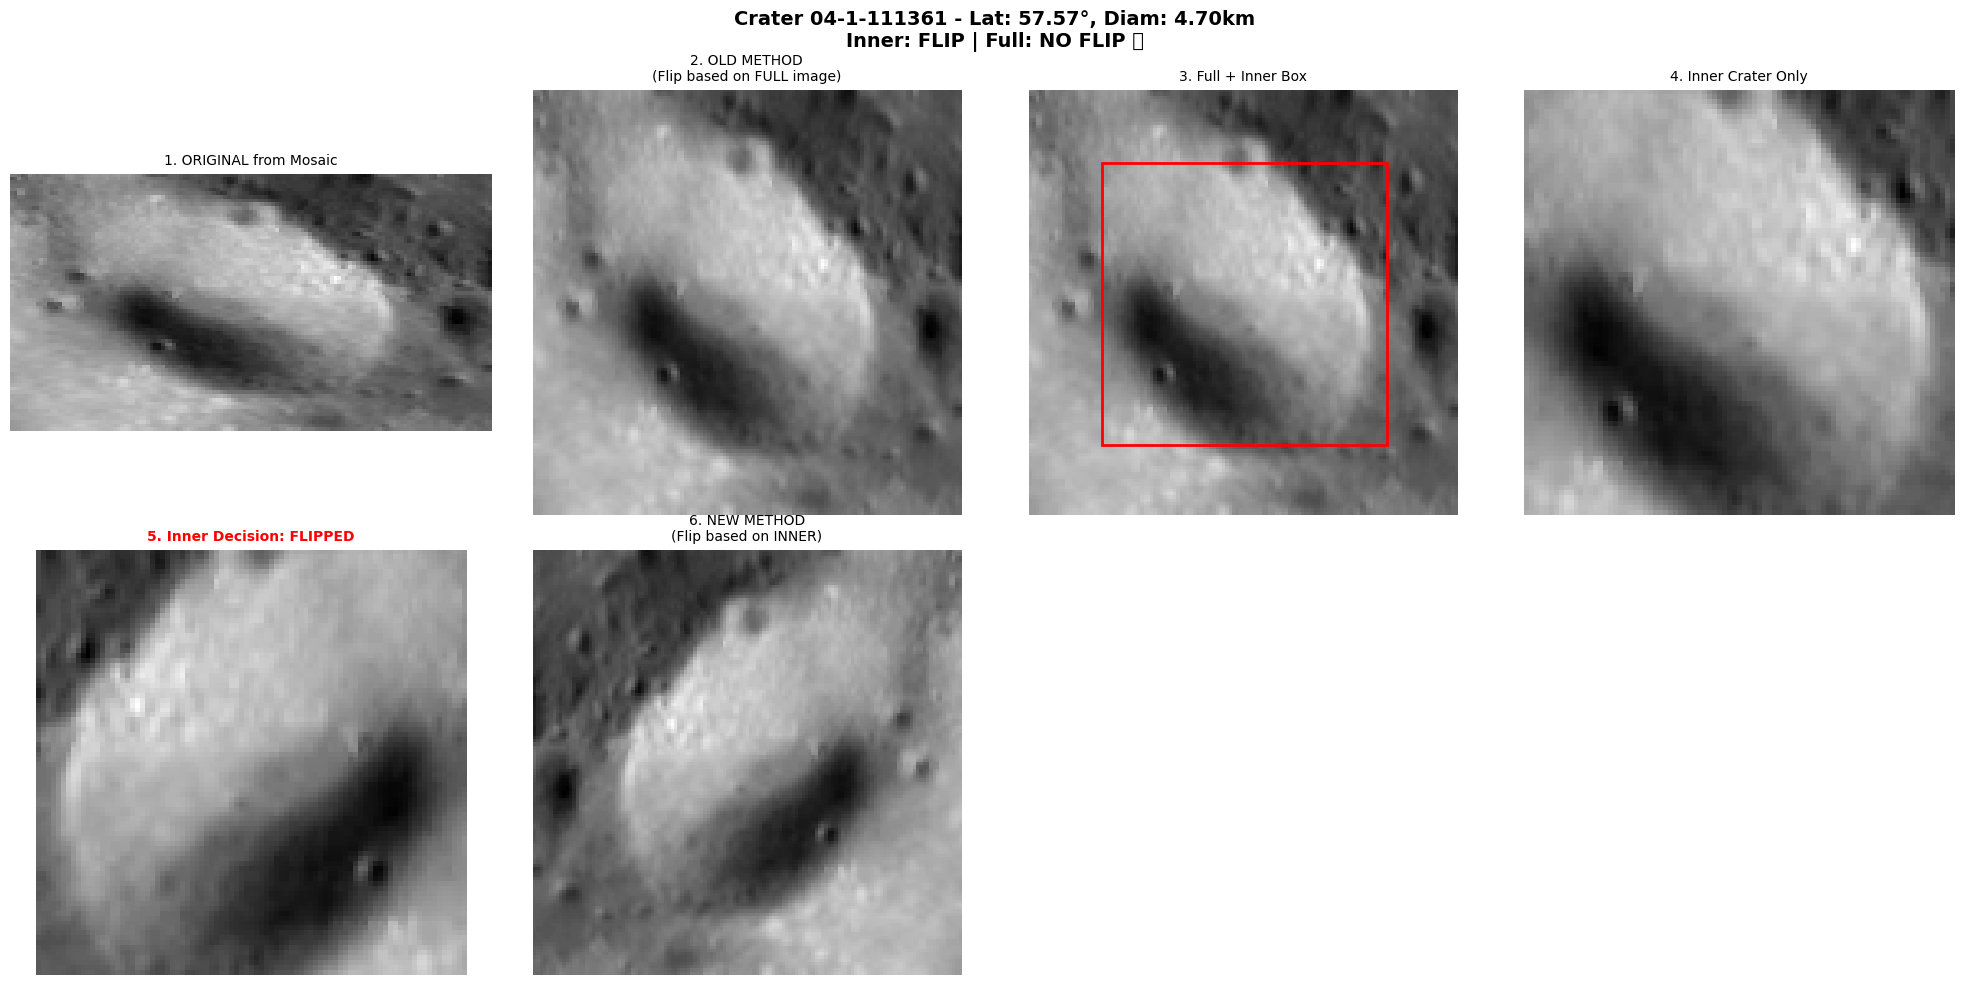


CRATER ID: 03-1-147507
Latitude: -54.74°
Longitude: 250.49°
Diameter: 2.68km


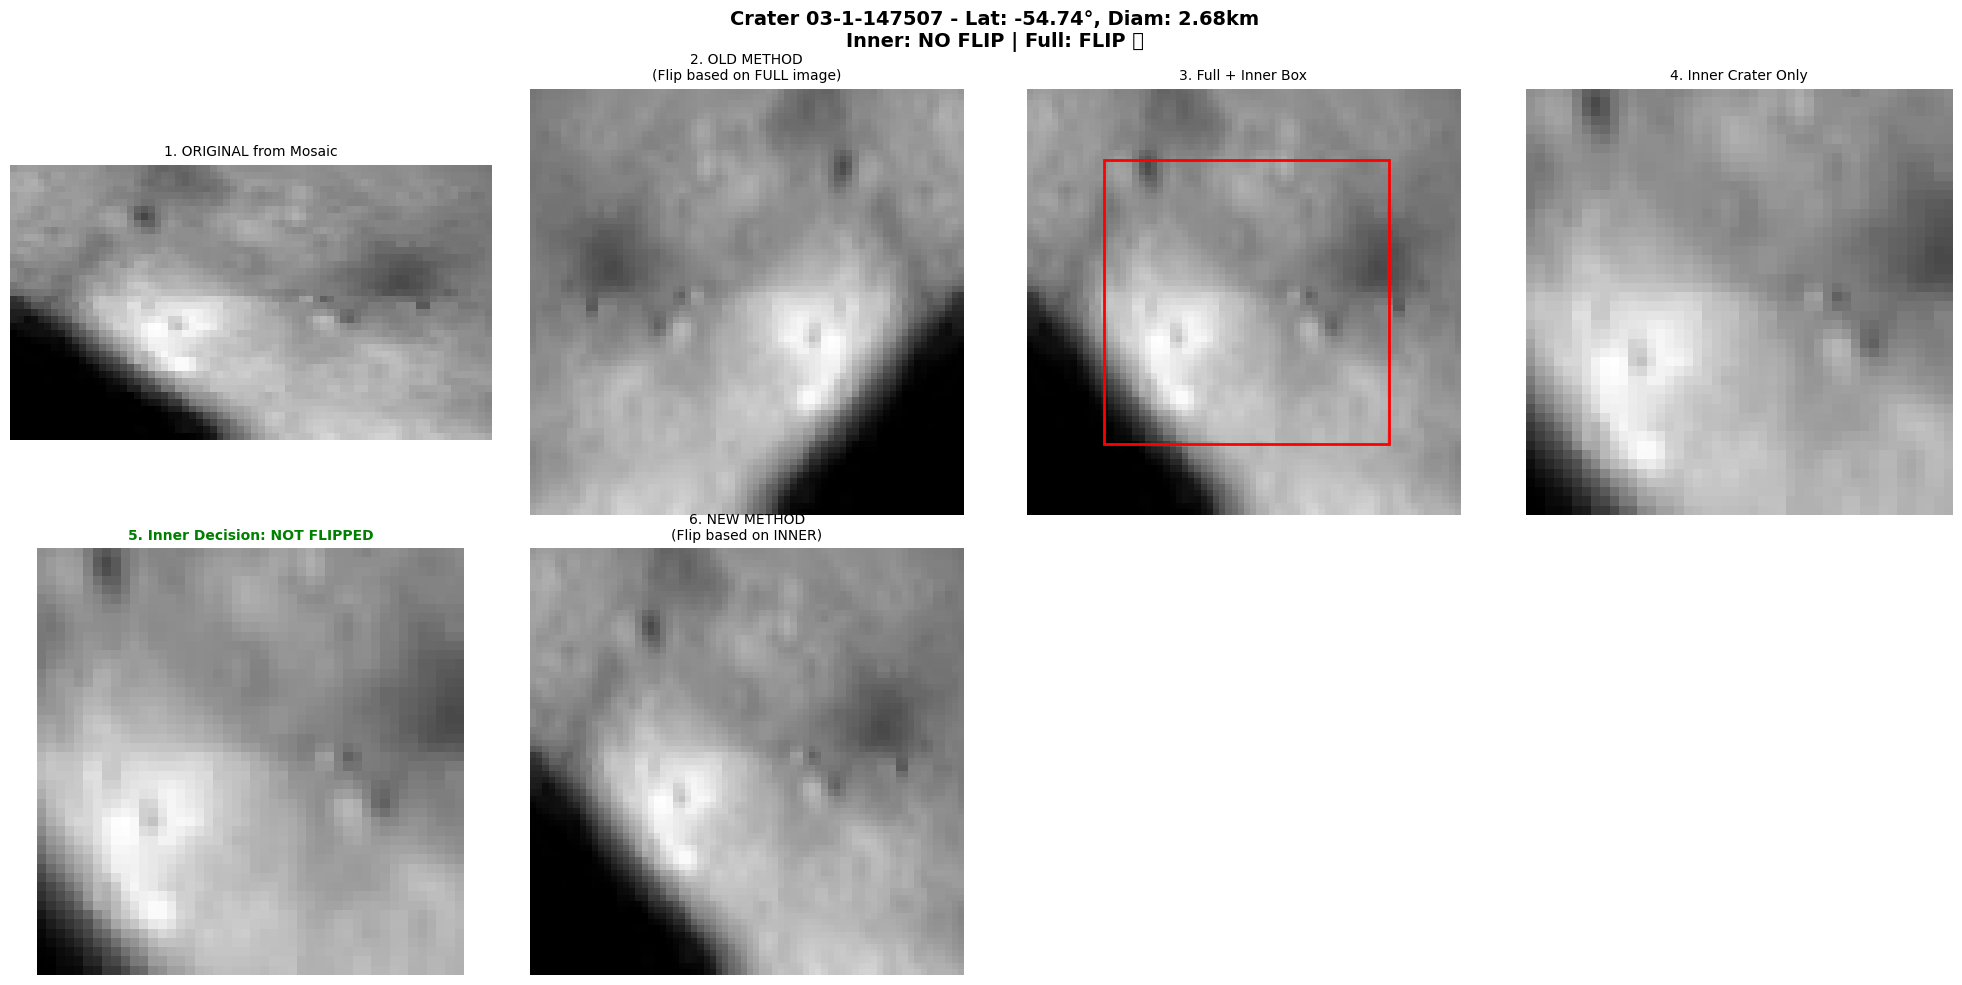


CRATER ID: 07-1-198674
Latitude: -51.84°
Longitude: 9.51°
Diameter: 1.30km


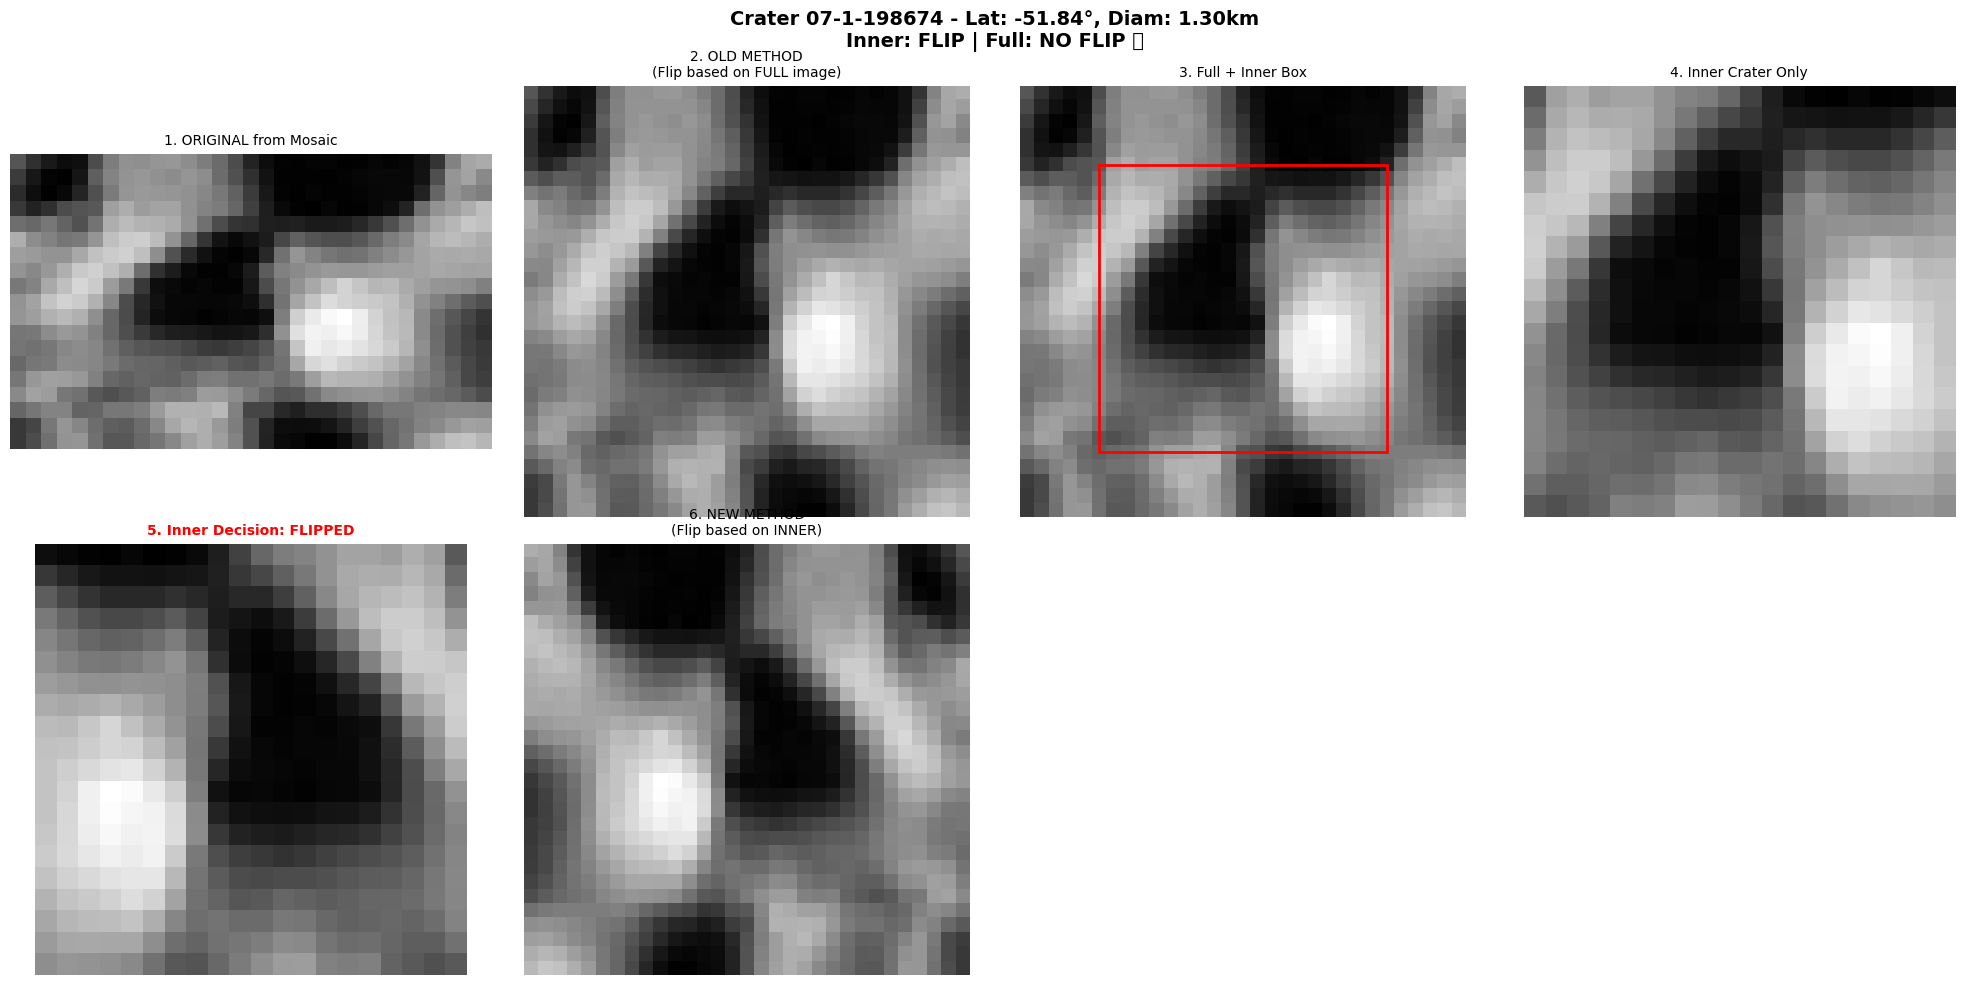


CRATER ID: 03-1-031633
Latitude: -10.51°
Longitude: 206.28°
Diameter: 2.13km


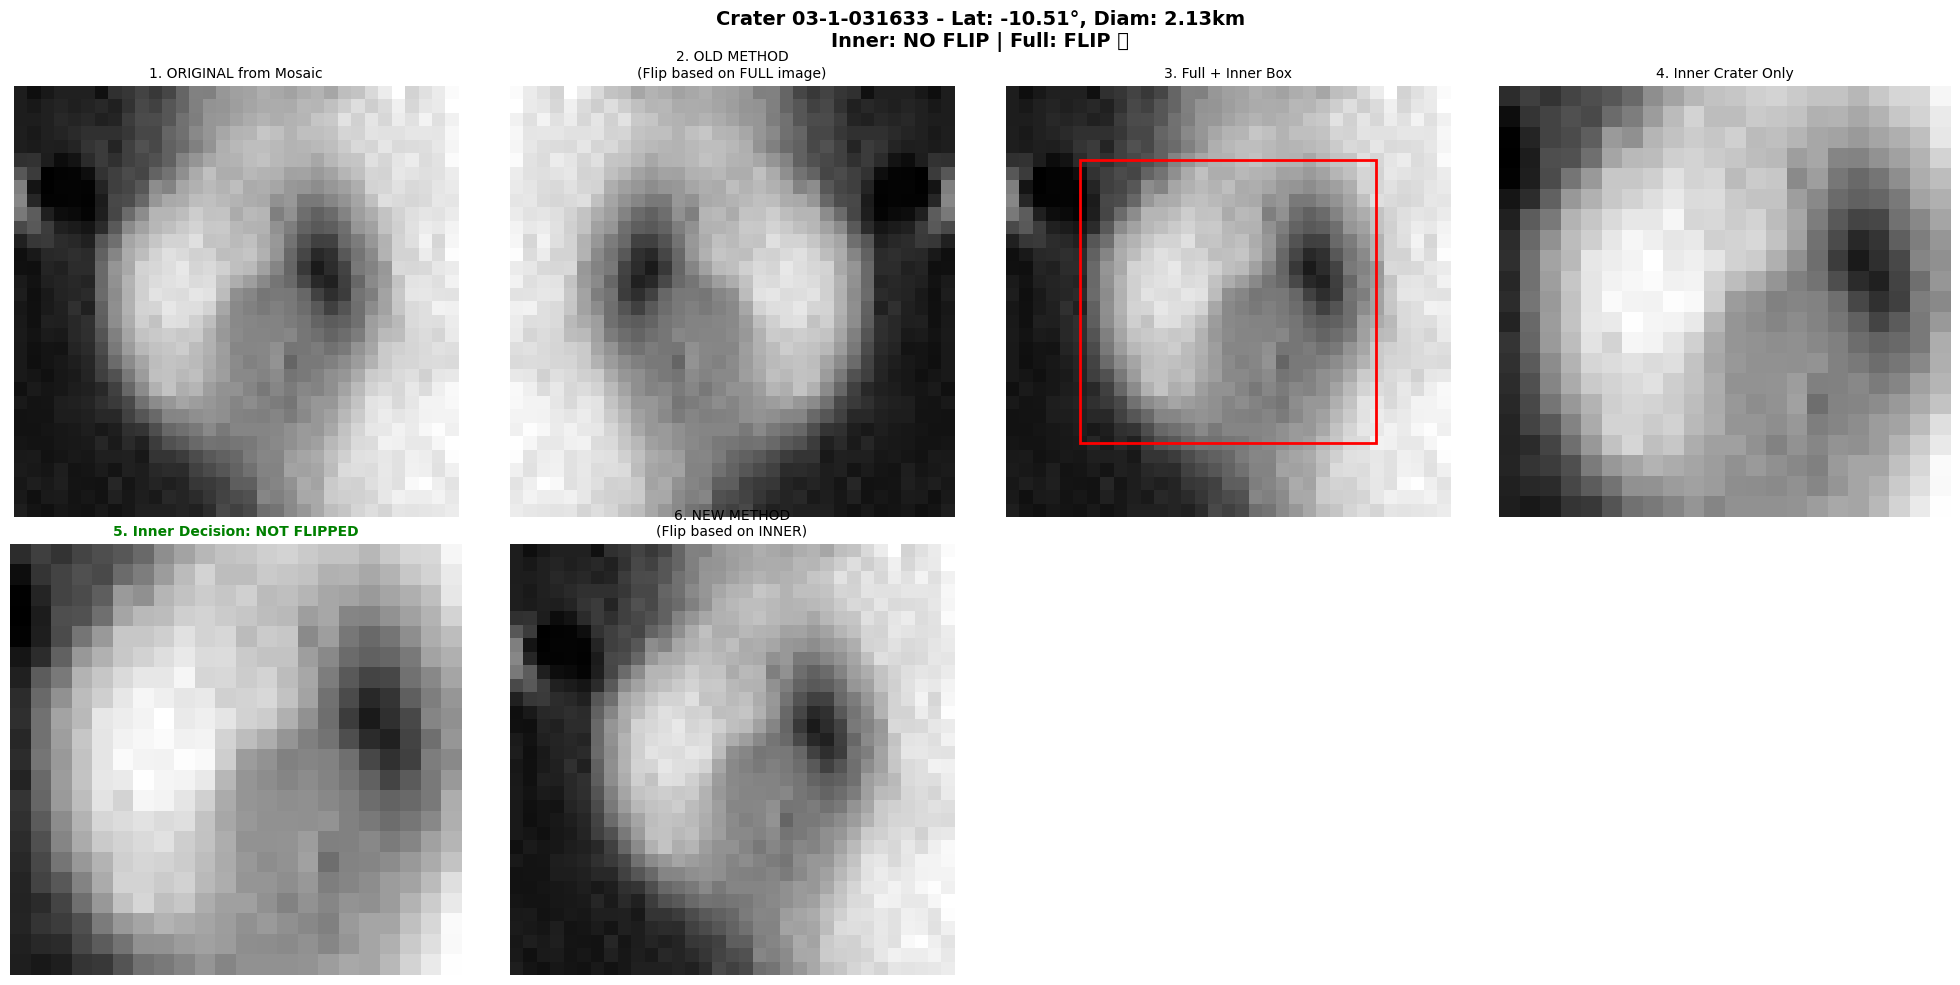


CRATER ID: 07-1-223797
Latitude: -58.18°
Longitude: 73.34°
Diameter: 4.58km


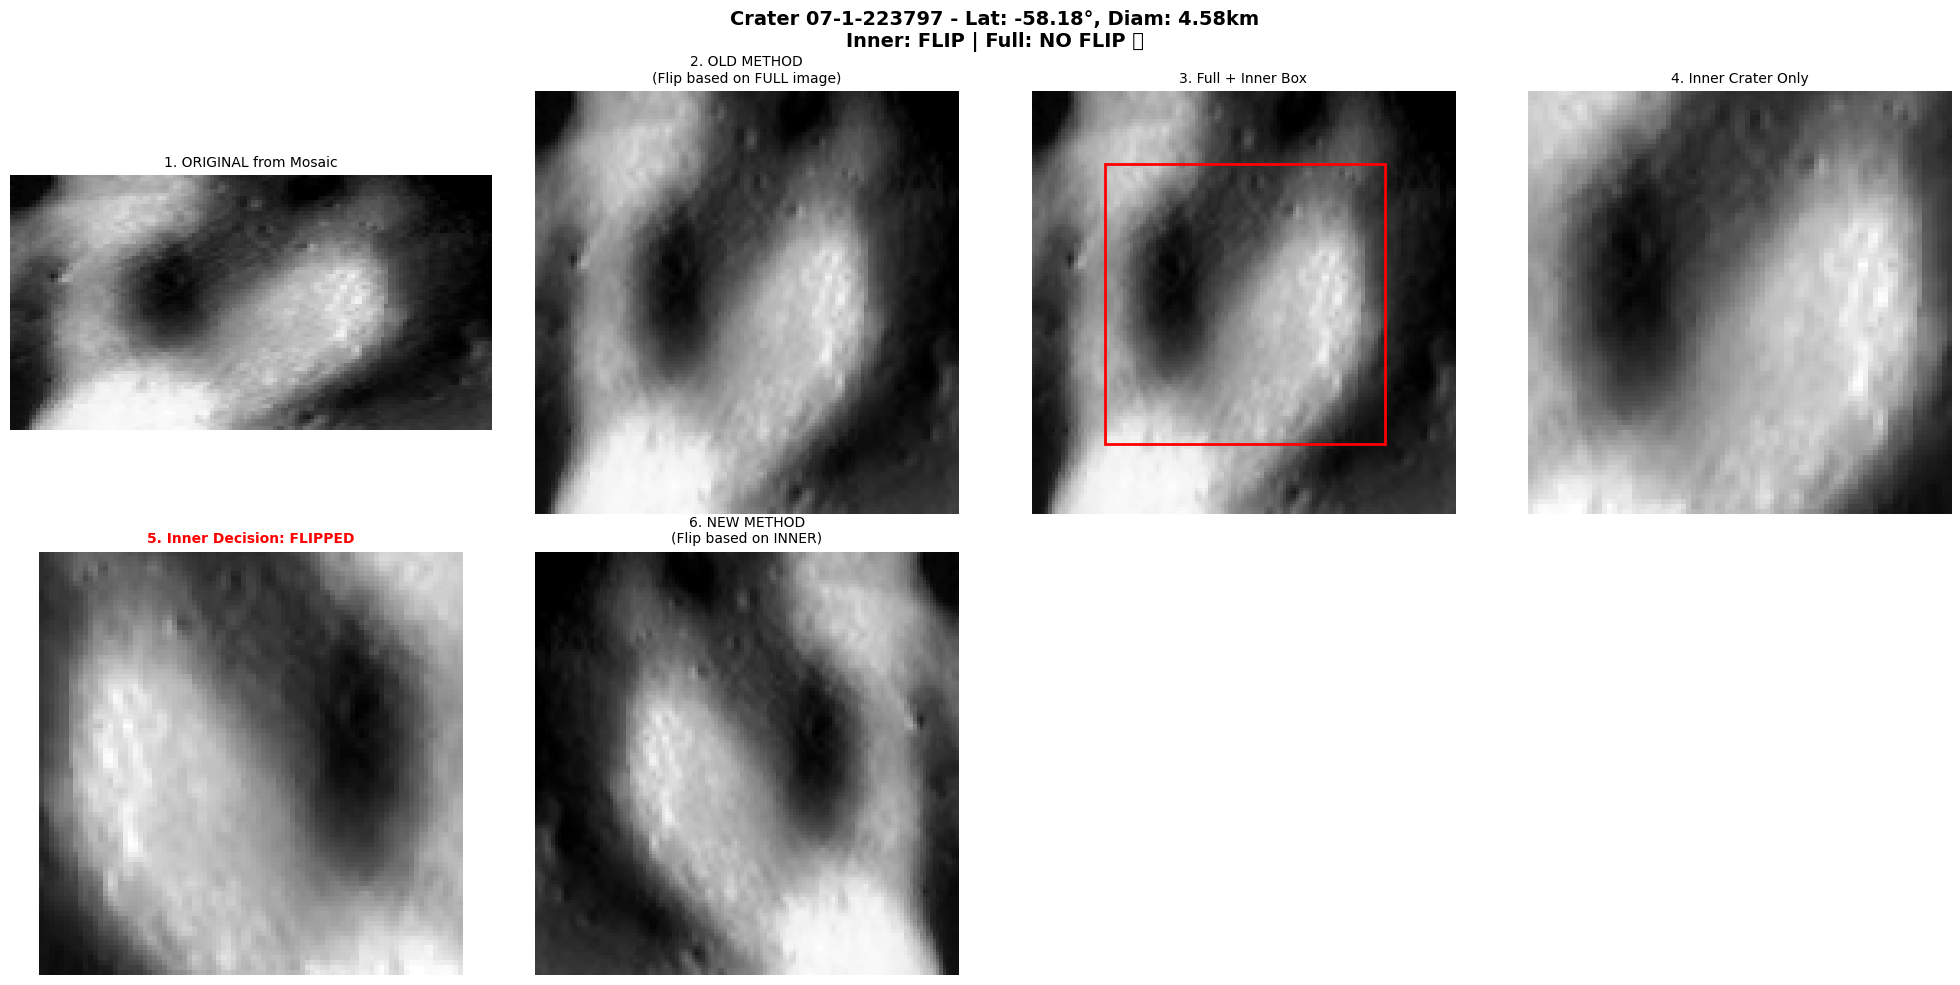

In [23]:
# Cell 5: Process and Visualize

with rasterio.open(map_file) as map_ref:
    transformer = pyproj.Transformer.from_crs(
        craters_crs, map_ref.crs.to_string(), always_xy=True
    )
    
    for crater in test_craters:
        crater_id = crater['CRATER_ID']
        lat = crater['LAT_CIRC_IMG']
        lon = crater['LON_CIRC_IMG']
        diam_km = crater['DIAM_CIRC_IMG']
        
        print(f"\n{'='*80}")
        print(f"CRATER ID: {crater_id}")
        print(f"Latitude: {lat:.2f}°")
        print(f"Longitude: {lon:.2f}°")
        print(f"Diameter: {diam_km:.2f}km")
        print(f"{'='*80}")
        
        # Get original raw image from mosaic
        original_raw = crop_crater_raw(
            map_ref, lat, lon, diam_km, offset, transformer
        )
        
        # Get processed image (old method)
        full_processed = crop_crater_original(
            map_ref, lat, lon, diam_km, offset, transformer
        )
        
        # Get new method components
        new_method = crop_crater_new_method(
            map_ref, lat, lon, diam_km, offset, transformer
        )
        
        # Cell 5: Process and Visualize (UPDATE lines after getting new_method)

        # Get original raw image from mosaic
        original_raw = crop_crater_raw(
            map_ref, lat, lon, diam_km, offset, transformer
        )
        
        # Get OLD method result (flipped based on FULL image)
        old_method_result = crop_crater_original(
            map_ref, lat, lon, diam_km, offset, transformer
        )
        
        # Get NEW method components
        new_method = crop_crater_new_method(
            map_ref, lat, lon, diam_km, offset, transformer
        )
        
        # Cell 5: Process and Visualize (UPDATE lines after getting new_method)

        # Get original raw image from mosaic
        original_raw = crop_crater_raw(
            map_ref, lat, lon, diam_km, offset, transformer
        )
        
        # Get OLD method result (flipped based on FULL image)
        old_method_result = crop_crater_original(
            map_ref, lat, lon, diam_km, offset, transformer
        )
        
        # Get NEW method components
        new_method = crop_crater_new_method(
            map_ref, lat, lon, diam_km, offset, transformer
        )
        
        # For visualization - also get full image flipped by FULL decision
        if new_method['should_flip_full']:
            full_flipped_by_full = np.fliplr(new_method['full_image_no_flip'])
        else:
            full_flipped_by_full = new_method['full_image_no_flip']
        
        # Create visualization
        fig = plt.figure(figsize=(20, 10))
        
        # ax1: Original
        ax1 = plt.subplot(2, 4, 1)
        ax1.imshow(original_raw, cmap='gray')
        ax1.set_title(f"1. ORIGINAL from Mosaic", fontsize=10)
        ax1.axis('off')
        
        # ax2: OLD method result
        ax2 = plt.subplot(2, 4, 2)
        ax2.imshow(old_method_result, cmap='gray')
        ax2.set_title(f"2. OLD METHOD\n(Flip based on FULL image)", fontsize=10)
        ax2.axis('off')
        
        # ax3: Full image with inner crater box
        ax3 = plt.subplot(2, 4, 3)
        ax3.imshow(new_method['full_image_no_flip'], cmap='gray')
        bbox = new_method['inner_bbox']
        rect = plt.Rectangle((bbox[0], bbox[1]), bbox[2]-bbox[0], bbox[3]-bbox[1], 
                             linewidth=2, edgecolor='red', facecolor='none')
        ax3.add_patch(rect)
        ax3.set_title(f"3. Full + Inner Box", fontsize=10)
        ax3.axis('off')
        
        # ax4: Inner crater only
        ax4 = plt.subplot(2, 4, 4)
        ax4.imshow(new_method['inner_crater'], cmap='gray')
        ax4.set_title(f"4. Inner Crater Only", fontsize=10)
        ax4.axis('off')
        
        # ax5: Inner crater decision
        ax5 = plt.subplot(2, 4, 5)
        ax5.imshow(new_method['inner_crater_flipped'], cmap='gray')
        decision = "FLIPPED" if new_method['should_flip_inner'] else "NOT FLIPPED"
        ax5.set_title(f"5. Inner Decision: {decision}", 
                     fontsize=10, color='red' if new_method['should_flip_inner'] else 'green',
                     fontweight='bold')
        ax5.axis('off')
        
        # ax6: NEW method result (based on inner)
        ax6 = plt.subplot(2, 4, 6)
        ax6.imshow(new_method['full_image_flipped'], cmap='gray')
        ax6.set_title(f"6. NEW METHOD\n(Flip based on INNER)", fontsize=10)
        ax6.axis('off')
        
        
        # Title
        match_old_inner = "✅" if new_method['should_flip_inner'] == new_method['should_flip_full'] else "❌"
        fig.suptitle(
            f"Crater {crater_id} - Lat: {lat:.2f}°, Diam: {diam_km:.2f}km\n"
            f"Inner: {'FLIP' if new_method['should_flip_inner'] else 'NO FLIP'} | "
            f"Full: {'FLIP' if new_method['should_flip_full'] else 'NO FLIP'} {match_old_inner}",
            fontsize=14, fontweight='bold'
        )
        
        plt.tight_layout()
        plt.show()